## This notebook is for building a image search function using CLIP model

Dataset used for images https://huggingface.co/datasets/SomeBottle/imagenet_50_224x224

In [127]:
dataset_path = "F://Handsongenai/projects/images/imagenet_50_224/imagenet_50_224/train"
save_csv_path = "F://HandsonGenAi/projects/"

model_version = "openai/clip-vit-base-patch32" #Changing the model can change the dimensions of encoded images

In [128]:
from torchvision import transforms
from torch.utils.data import DataLoader, Dataset
from genaibook.core import get_device
from transformers import CLIPModel, CLIPProcessor
import torch
import os
import numpy as np
from PIL import Image


device = get_device()

        



In [129]:
class CustomDataset(Dataset):
    """Custom dataset for the dataloader. Returns image, label and the image path"""

    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.samples = []
        for label_idx, class_name in enumerate(sorted(os.listdir(root_dir))):
            class_dir = os.path.join(root_dir, class_name)
            if not os.path.isdir(class_dir):
                continue
            for file_name in os.listdir(class_dir):
                self.samples.append((os.path.join(class_dir, file_name), label_idx))

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]

        # Load image
        try:
            image = Image.open(img_path)
        except Exception as e:
            raise RuntimeError(f"Error loading image {img_path}: {e}")

        # Apply transforms if provided
        if self.transform:
            image = self.transform(image)

        return image, label, img_path  # Return path as well

In [130]:


dataset = CustomDataset(dataset_path,transform=transforms.PILToTensor())
loader = DataLoader(dataset, batch_size=32)
clip = CLIPModel.from_pretrained(model_version).to(device)
processor = CLIPProcessor.from_pretrained(model_version) #Pre-processor


In [132]:
import pandas as pd
import tqdm


embeddings_full = []

with torch.no_grad():
    if not os.path.exists(f"{save_csv_path}/encoded_images_ch3.csv"): #If the encoded csv exists no point in running
        for images, labels, paths in tqdm.tqdm(loader,desc="Encoding images"):

            processed_batch = processor(images,return_tensors="pt",do_normalize=False)

            pixel_values = processed_batch["pixel_values"].to(device)

            
            encoded = clip.vision_model(pixel_values)
            image_embeddings = clip.visual_projection(encoded.pooler_output)
            image_embeddings = image_embeddings.cpu().numpy()

            for emb, label, path in zip(image_embeddings,labels,paths):
                row = emb.tolist()
                row.append(label)
                row.append(path)
                embeddings_full.append(row)
            
            

        temp_dataframe = pd.DataFrame(embeddings_full)
        temp_dataframe.to_csv(f"{save_csv_path}/encoded_images_ch3.csv",mode="x") #Create a csv file for the encoded images.


Encoding images: 100%|██████████| 1563/1563 [03:12<00:00,  8.11it/s]


## Text search

In [177]:
text_search = "a photo of a lizard"
with torch.inference_mode():
    text_input = processor(text=text_search,return_tensors="pt",padding=True)
    text_input = {k: v.to(device) for k,v in text_input.items()}
    text_encoded = clip.text_model(**text_input)
    
    text_encoded = text_encoded.pooler_output
    text_encoded = clip.text_projection(text_encoded)

    text_encoded = text_encoded.cpu()

In [178]:
image_embeddings_df  = pd.read_csv(f"{save_csv_path}/encoded_images_ch3.csv")


In [183]:
image_embeddings_df

,Unnamed: 0,0,1,2,3,4,5,6,7,8,...,504,505,506,507,508,509,510,511,512,513
0,0,-0.188208,0.326976,0.289255,-0.066526,0.106275,-0.257529,0.115905,0.614193,0.422092,...,0.417028,-0.313143,-0.261084,0.672357,-0.066724,0.545626,0.185463,-0.269964,tensor(0),F://Handsongenai/projects/images/imagenet_50_2...
1,1,-0.130392,-0.224265,0.002162,-0.240078,-0.098508,-0.555218,-0.007667,-0.145091,0.631062,...,-0.398125,-0.029956,-0.010028,0.471319,0.047372,0.500022,0.409053,-0.023133,tensor(0),F://Handsongenai/projects/images/imagenet_50_2...
2,2,-0.363778,0.061955,-0.130426,0.446013,0.261999,-0.822838,-0.093758,0.563564,0.291185,...,1.146086,-0.150891,-0.236155,-0.072726,-0.073482,0.740585,-0.348861,-0.046557,tensor(0),F://Handsongenai/projects/images/imagenet_50_2...
3,3,0.244870,-0.294133,0.082220,-0.112310,-0.182776,-0.505898,0.351132,-0.070310,0.388665,...,-0.142815,-0.204686,-0.140795,0.144048,-0.019861,0.255266,-0.016161,0.165711,tensor(0),F://Handsongenai/projects/images/imagenet_50_2...
4,4,0.250536,-0.052274,0.177352,-0.196531,0.095702,-0.280030,0.196445,-0.010882,0.353850,...,-0.072093,-0.162404,-0.120983,0.130740,0.194082,0.278255,0.224722,0.173425,tensor(0),F://Handsongenai/projects/images/imagenet_50_2...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,49995,-0.498782,0.213832,-0.084679,0.283807,0.220378,-0.171236,-0.008235,0.450524,0.639691,...,0.522853,-0.235719,0.093366,0.300737,-0.225446,0.690347,0.094419,-0.148471,tensor(49),F://Handsongenai/projects/images/imagenet_50_2...
49996,49996,-0.100675,0.137613,0.287657,0.315060,0.028770,-0.056527,0.227095,0.366422,0.301727,...,0.749203,-0.257564,0.057273,0.513682,0.029981,0.820247,0.212923,-0.264834,tensor(49),F://Handsongenai/projects/images/imagenet_50_2...
49997,49997,0.169504,0.224211,0.236360,0.180353,0.083042,-0.110485,0.077004,0.407838,0.630722,...,0.291873,-0.586135,-0.246093,-0.064684,0.251367,0.427598,0.091449,0.035666,tensor(49),F://Handsongenai/projects/images/imagenet_50_2...
49998,49998,-0.196662,0.314951,0.354651,0.236449,0.153300,-0.199369,0.169153,0.339143,0.516500,...,-0.172579,0.056503,-0.824039,0.235032,0.192361,0.430120,-0.165400,-0.199218,tensor(49),F://Handsongenai/projects/images/imagenet_50_2...


In [184]:
image_embeddings_matrix = torch.tensor(image_embeddings_df.drop(axis=1,labels=["Unnamed: 0","513","512"]).values)

In [185]:
text_encoded = text_encoded / text_encoded.norm(p=2,dim=-1,keepdim=True)
image_embeddings_matrix = image_embeddings_matrix / image_embeddings_matrix.norm(p=2,dim=-1,keepdim=True)




In [186]:
text_encoded = text_encoded.to(torch.float64)

similarities = torch.matmul(text_encoded,image_embeddings_matrix.T)*100
probabilities = similarities.softmax(dim=1)

In [187]:
search_results_n = 5
values,indices = torch.topk(probabilities,search_results_n)

top_result_paths = image_embeddings_df["513"][indices.squeeze().tolist()]

probabilities for each image: tensor([[0.0103, 0.0052, 0.0050, 0.0048, 0.0048]], dtype=torch.float64)


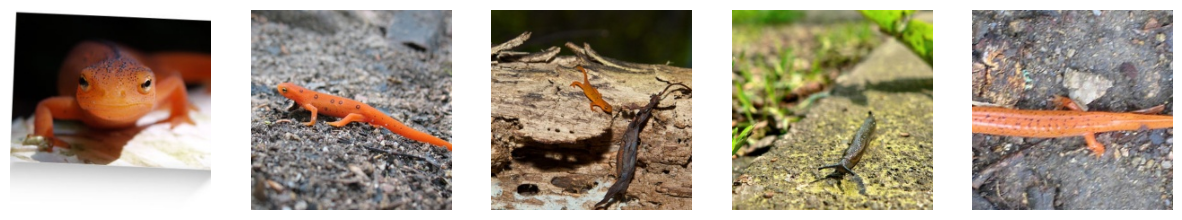

In [ ]:
from genaibook.core import show_images, show_image

results = []


for idx in indices.squeeze():
    idx = idx.item()
    image = Image.open(top_result_paths[idx])
    results.append(image)
show_images(results,nrows=1)

print("Probabilities for each image:",values)

## Image search


In [191]:
#Define path for the image to search
search_image_path = "F:/HandsonGenAi/projects/Images/imagenet_50_224/imagenet_50_224/val/n01855672/ILSVRC2012_val_00003364.jpeg"


In [192]:
search_img = Image.open(search_image_path)

search_img = processor(search_img,return_tensors="pt")
search_img = search_img["pixel_values"].to(device)

with torch.inference_mode():
    output = clip.vision_model(search_img)

    search_img_emb = output.pooler_output
    search_img_emb = clip.visual_projection(search_img_emb)



In [193]:
search_img_emb = search_img_emb / search_img_emb.norm(p=2,dim=-1,keepdim=True)
search_img_emb = search_img_emb.cpu()

In [194]:
search_img_emb = search_img_emb.to(torch.float64)

In [195]:
img_similarities = torch.matmul(search_img_emb,image_embeddings_matrix.T)

In [196]:
search_results_n = 5
values,indices = torch.topk(img_similarities,search_results_n)

top_result_paths = image_embeddings_df["513"][indices.squeeze().tolist()]

F://Handsongenai/projects/images/imagenet_50_224/imagenet_50_224/train\n01855672\n01855672_7260.jpeg
F://Handsongenai/projects/images/imagenet_50_224/imagenet_50_224/train\n01855672\n01855672_6667.jpeg
F://Handsongenai/projects/images/imagenet_50_224/imagenet_50_224/train\n01855672\n01855672_5144.jpeg
F://Handsongenai/projects/images/imagenet_50_224/imagenet_50_224/train\n01855672\n01855672_13383.jpeg
F://Handsongenai/projects/images/imagenet_50_224/imagenet_50_224/train\n01855672\n01855672_11860.jpeg


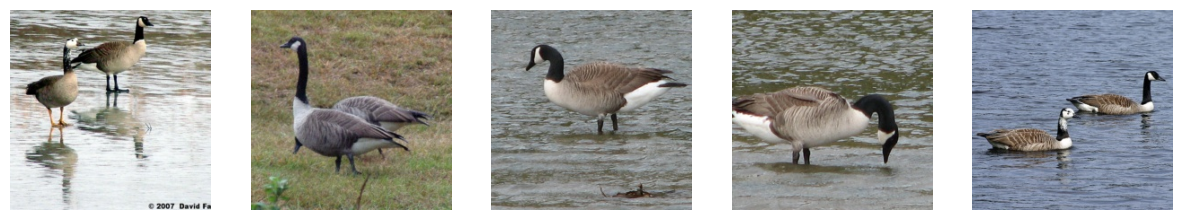

In [197]:
results = []


for idx in indices.squeeze():
    idx = idx.item()
    print(top_result_paths[idx])
    image = Image.open(top_result_paths[idx])
    results.append(image)
show_images(results,nrows=1)

<Axes: >

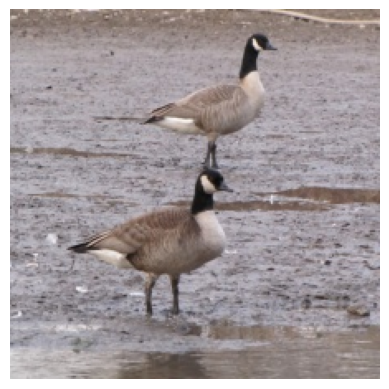

In [198]:
image_2 = Image.open(search_image_path)
show_image(image_2)